# Prespecified multi-dataset search for a confirmatory calibrated-DPD application

The earlier AutoClaims and dataCar analyses failed strict common-mean
compatibility checks. Rather than weakening the criterion after seeing those
failures, this notebook performs a prespecified search across four public
insurance datasets:

1. `AutoClaims`;
2. `dataCar`;
3. `AutoBi`;
4. `WorkersComp`.

For every dataset, the observations are divided into:

- 70% development;
- 30% untouched final evaluation.

Candidate pairs are screened in the development sample using repeated internal
splits. Among stable candidates, the notebook calibrates the DPD tuning
parameter and evaluates development-stage precision and contamination
performance. The dataset/pair is selected only from development information.
The final sample remains untouched until one candidate has been frozen.

The final result is called top performance only if calibrated DPD:

- passes the final common-mean compatibility requirement;
- ranks first in nonparametric bootstrap SE;
- ranks first in contaminated RMSE in at least two stress scenarios;
- ranks first in contamination displacement in at least two stress scenarios;
- remains within 5% of the constrained MLE estimate.

The notebook reports an unfavorable result rather than changing the
confirmatory rule.


In [1]:
# ============================================================
# 1. Imports and configuration
# ============================================================

from itertools import combinations
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import skew


SEED = 20260801
PUBLICATION_MODE = False

if PUBLICATION_MODE:
    N_STABILITY_SPLITS = 100
    R_TAU_CALIBRATION = 250
    R_DEVELOPMENT_BOOTSTRAP = 500
    R_DEVELOPMENT_STRESS = 300
    R_FINAL_BOOTSTRAP = 1000
    R_FINAL_STRESS = 500
    CALIBRATION_SAMPLE_CAP = 3000
    MAX_SHORTLIST = 12
else:
    N_STABILITY_SPLITS = 25
    R_TAU_CALIBRATION = 20
    R_DEVELOPMENT_BOOTSTRAP = 80
    R_DEVELOPMENT_STRESS = 60
    R_FINAL_BOOTSTRAP = 200
    R_FINAL_STRESS = 100
    CALIBRATION_SAMPLE_CAP = 1200
    MAX_SHORTLIST = 8

DEVELOPMENT_FRACTION = 0.70

MEDIAN_GAP_LIMIT = 0.075
Q90_GAP_LIMIT = 0.12
MIN_COMPATIBLE_SPLIT_RATE = 0.75
FINAL_GAP_LIMIT = 0.10

MIN_SHAPE_RATIO = 1.10
MIN_SKEWNESS = 0.25

CLEAN_EFFICIENCY_FLOOR = 0.95
MIN_FIT_SUCCESS_RATE = 0.95
MAX_DPD_MLE_DRIFT = 0.05

# Per-dataset sample-size safeguards.
DATASET_MINIMUMS = {
    "AutoClaims": {
        "development": 100,
        "internal": 35,
        "final": 60,
    },
    "dataCar": {
        "development": 120,
        "internal": 40,
        "final": 70,
    },
    "AutoBi": {
        "development": 70,
        "internal": 25,
        "final": 40,
    },
    "WorkersComp": {
        "development": 40,
        "internal": 15,
        "final": 20,
    },
}

TAU_GRID = np.array(
    [
        0.0,
        0.00010,
        0.00025,
        0.00050,
        0.00075,
        0.00100,
        0.00150,
        0.00200,
        0.00300,
        0.00500,
        0.00750,
        0.01000,
        0.01500,
        0.02000,
        0.03000,
        0.05000,
        0.07500,
        0.10000,
    ],
    dtype=float,
)

CALIBRATION_CONTAMINATION = {
    "scenario": "1pct_x5",
    "epsilon": 0.010,
    "factor": 5.0,
}

STRESS_SCENARIOS = [
    {
        "scenario": "0.5pct_x5",
        "epsilon": 0.005,
        "factor": 5.0,
    },
    {
        "scenario": "1pct_x3",
        "epsilon": 0.010,
        "factor": 3.0,
    },
    {
        "scenario": "1pct_x5",
        "epsilon": 0.010,
        "factor": 5.0,
    },
]

LOCAL_DATA_FILES = {
    "AutoClaims": None,
    "dataCar": None,
    "AutoBi": None,
    "WorkersComp": None,
}

OUTPUT_DIR = Path(
    "multidataset_common_mean_dpd_outputs"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 320)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}",
)

print("PUBLICATION_MODE =", PUBLICATION_MODE)
print("Development fraction =", DEVELOPMENT_FRACTION)
print("Stability splits =", N_STABILITY_SPLITS)


PUBLICATION_MODE = False
Development fraction = 0.7
Stability splits = 25


In [2]:
# ============================================================
# 2. Benchmark estimators and common-mean gamma likelihood
# ============================================================

def gamma_logpdf_values(z, alpha, beta):
    z = np.asarray(z, dtype=float)

    return (
        (alpha - 1.0) * np.log(z)
        - z / beta
        - alpha * np.log(beta)
        - gammaln(alpha)
    )


def est_equal(x, y):
    return float(0.5 * (np.mean(x) + np.mean(y)))


def est_pooled(x, y):
    n1 = len(x)
    n2 = len(y)

    return float(
        (n1 * np.mean(x) + n2 * np.mean(y))
        / (n1 + n2)
    )


def est_plugin(x, y):
    n1 = len(x)
    n2 = len(y)

    mean1 = np.mean(x)
    mean2 = np.mean(y)
    var1 = np.var(x, ddof=1)
    var2 = np.var(y, ddof=1)

    eps = 1.0e-12
    weight1 = n1 / max(var1, eps)
    weight2 = n2 / max(var2, eps)

    return float(
        (weight1 * mean1 + weight2 * mean2)
        / (weight1 + weight2)
    )


def mom_alpha_estimates(x, y):
    mean1 = np.mean(x)
    mean2 = np.mean(y)
    var1 = np.var(x, ddof=1)
    var2 = np.var(y, ddof=1)

    eps = 1.0e-12

    return (
        float(mean1 * mean1 / max(var1, eps)),
        float(mean2 * mean2 / max(var2, eps)),
    )


def est_mom(x, y):
    n1 = len(x)
    n2 = len(y)

    mean1 = np.mean(x)
    mean2 = np.mean(y)
    alpha1, alpha2 = mom_alpha_estimates(x, y)

    weight1 = n1 * alpha1
    weight2 = n2 * alpha2

    return float(
        (weight1 * mean1 + weight2 * mean2)
        / (weight1 + weight2)
    )


def moment_start_values(x, y):
    n1 = len(x)
    n2 = len(y)

    mean1 = np.mean(x)
    mean2 = np.mean(y)
    var1 = np.var(x, ddof=1)
    var2 = np.var(y, ddof=1)

    eps = 1.0e-10
    mu0 = max(
        (n1 * mean1 + n2 * mean2) / (n1 + n2),
        eps,
    )
    alpha10 = max(mean1 * mean1 / max(var1, eps), 0.05)
    alpha20 = max(mean2 * mean2 / max(var2, eps), 0.05)

    return np.log([mu0, alpha10, alpha20])


def winsor_start_values(x, y, lower=0.05, upper=0.95):
    xw = np.clip(
        x,
        np.quantile(x, lower),
        np.quantile(x, upper),
    )
    yw = np.clip(
        y,
        np.quantile(y, lower),
        np.quantile(y, upper),
    )

    return moment_start_values(xw, yw)


def neg_loglik_common_mean(theta, x, y):
    log_mu, log_alpha1, log_alpha2 = theta

    mu = np.exp(log_mu)
    alpha1 = np.exp(log_alpha1)
    alpha2 = np.exp(log_alpha2)

    beta1 = mu / alpha1
    beta2 = mu / alpha2

    value = -(
        np.sum(gamma_logpdf_values(x, alpha1, beta1))
        + np.sum(gamma_logpdf_values(y, alpha2, beta2))
    )

    return float(value) if np.isfinite(value) else 1.0e100


def mle_common_mean_params(x, y):
    starts = [
        moment_start_values(x, y),
        winsor_start_values(x, y, 0.05, 0.95),
        winsor_start_values(x, y, 0.10, 0.90),
    ]

    bounds = [
        (np.log(1.0e-8), np.log(1.0e9)),
        (np.log(1.0e-6), np.log(1.0e6)),
        (np.log(1.0e-6), np.log(1.0e6)),
    ]

    best_theta = None
    best_value = np.inf

    for start in starts:
        result = minimize(
            neg_loglik_common_mean,
            start,
            args=(x, y),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 500, "ftol": 1.0e-11},
        )

        if not (
            result.success
            and np.all(np.isfinite(result.x))
        ):
            continue

        value = neg_loglik_common_mean(result.x, x, y)

        if np.isfinite(value) and value < best_value:
            best_value = value
            best_theta = result.x.copy()

    if best_theta is None:
        fallback = moment_start_values(x, y)

        return (
            float(np.exp(fallback[0])),
            float(np.exp(fallback[1])),
            float(np.exp(fallback[2])),
            False,
        )

    return (
        float(np.exp(best_theta[0])),
        float(np.exp(best_theta[1])),
        float(np.exp(best_theta[2])),
        True,
    )


def est_better_component_plugin(x, y, mle_result=None):
    if mle_result is None:
        mle_result = mle_common_mean_params(x, y)

    _, alpha1, alpha2, _ = mle_result

    if len(x) * alpha1 >= len(y) * alpha2:
        return float(np.mean(x))

    return float(np.mean(y))


In [3]:
# ============================================================
# 3. Stable common-mean DPD estimator
# ============================================================

def dpd_integral_gamma(alpha, beta, tau):
    kappa = (1.0 + tau) * alpha - tau

    if alpha <= 0.0 or beta <= 0.0 or kappa <= 0.0:
        return np.inf

    log_value = (
        gammaln(kappa)
        - (1.0 + tau) * gammaln(alpha)
        - tau * np.log(beta)
        - kappa * np.log1p(tau)
    )

    if not np.isfinite(log_value) or log_value > 700.0:
        return np.inf

    return float(np.exp(log_value))


def dpd_group_objective(z, alpha, beta, tau):
    integral = dpd_integral_gamma(alpha, beta, tau)

    if not np.isfinite(integral):
        return 1.0e100

    log_density = gamma_logpdf_values(z, alpha, beta)
    centered_power_sum = np.sum(
        np.expm1(
            np.clip(
                tau * log_density,
                -745.0,
                700.0,
            )
        )
    )

    value = (
        len(z) * integral
        - ((1.0 + tau) / tau) * centered_power_sum
    )

    return float(value) if np.isfinite(value) else 1.0e100


def dpd_common_mean_objective(theta, x, y, tau):
    log_mu, log_alpha1, log_alpha2 = theta

    mu = np.exp(log_mu)
    alpha1 = np.exp(log_alpha1)
    alpha2 = np.exp(log_alpha2)

    beta1 = mu / alpha1
    beta2 = mu / alpha2

    value = (
        dpd_group_objective(x, alpha1, beta1, tau)
        + dpd_group_objective(y, alpha2, beta2, tau)
    )

    return float(value) if np.isfinite(value) else 1.0e100


def fit_dpd_common_mean(
    x,
    y,
    tau,
    mle_result=None,
    warm_start=None,
):
    if mle_result is None:
        mle_result = mle_common_mean_params(x, y)

    if tau <= 1.0e-12:
        return mle_result

    mu_mle, alpha1_mle, alpha2_mle, _ = mle_result

    starts = []

    if warm_start is not None:
        warm_start = np.asarray(warm_start, dtype=float)

        if (
            warm_start.shape == (3,)
            and np.all(np.isfinite(warm_start))
            and np.all(warm_start > 0.0)
        ):
            starts.append(np.log(warm_start))

    starts.extend(
        [
            np.log(
                [
                    max(mu_mle, 1.0e-8),
                    max(alpha1_mle, 1.0e-4),
                    max(alpha2_mle, 1.0e-4),
                ]
            ),
            moment_start_values(x, y),
            winsor_start_values(x, y, 0.05, 0.95),
            winsor_start_values(x, y, 0.10, 0.90),
        ]
    )

    bounds = [
        (np.log(1.0e-8), np.log(1.0e9)),
        (np.log(1.0e-4), np.log(1.0e6)),
        (np.log(1.0e-4), np.log(1.0e6)),
    ]

    best_theta = None
    best_value = np.inf

    for start in starts:
        result = minimize(
            dpd_common_mean_objective,
            start,
            args=(x, y, tau),
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": 500, "ftol": 1.0e-11},
        )

        if not (
            result.success
            and np.all(np.isfinite(result.x))
        ):
            continue

        value = dpd_common_mean_objective(
            result.x,
            x,
            y,
            tau,
        )

        if np.isfinite(value) and value < best_value:
            best_value = value
            best_theta = result.x.copy()

    if best_theta is None:
        return np.nan, np.nan, np.nan, False

    return (
        float(np.exp(best_theta[0])),
        float(np.exp(best_theta[1])),
        float(np.exp(best_theta[2])),
        True,
    )


def fit_tau_path(x, y, tau_grid):
    mle_result = mle_common_mean_params(x, y)
    rows = []
    warm_start = None

    for tau in np.sort(np.unique(tau_grid)):
        fit_result = fit_dpd_common_mean(
            x,
            y,
            float(tau),
            mle_result=mle_result,
            warm_start=warm_start,
        )

        mu_hat, alpha1_hat, alpha2_hat, success = fit_result

        if success:
            warm_start = (mu_hat, alpha1_hat, alpha2_hat)

        rows.append(
            {
                "tau": float(tau),
                "mu_hat": float(mu_hat),
                "alpha1_hat": float(alpha1_hat),
                "alpha2_hat": float(alpha2_hat),
                "success": bool(success),
            }
        )

    return pd.DataFrame(rows), mle_result


In [4]:
# ============================================================
# 4. Load and standardize all candidate datasets
# ============================================================

BASE_URLS = [
    (
        "https://vincentarelbundock.github.io/"
        "Rdatasets/csv/insuranceData/{name}.csv"
    ),
    (
        "https://raw.githubusercontent.com/"
        "vincentarelbundock/Rdatasets/master/"
        "csv/insuranceData/{name}.csv"
    ),
]


def normalize_name(value):
    return "".join(
        character
        for character in str(value).lower()
        if character.isalnum()
    )


def find_column(
    frame,
    aliases,
    required=True,
):
    lookup = {
        normalize_name(column): column
        for column in frame.columns
    }

    for alias in aliases:
        key = normalize_name(alias)

        if key in lookup:
            return lookup[key]

    if required:
        raise KeyError(
            f"None of the aliases {aliases} were found. "
            f"Available columns: {list(frame.columns)}"
        )

    return None


def load_rdataset(dataset_name):
    local_path = LOCAL_DATA_FILES.get(
        dataset_name
    )

    if local_path is not None:
        path = Path(local_path)

        if not path.exists():
            raise FileNotFoundError(
                f"Local file not found: {path}"
            )

        return (
            pd.read_csv(path),
            f"local file: {path}",
        )

    errors = []

    for template in BASE_URLS:
        url = template.format(
            name=dataset_name
        )

        try:
            frame = pd.read_csv(url)

            if len(frame) > 0:
                return frame, url
        except Exception as error:
            errors.append(
                f"{url}: {error}"
            )

    raise RuntimeError(
        f"{dataset_name} could not be loaded.\n"
        + "\n".join(errors)
    )


def remove_row_name_columns(frame):
    return frame.drop(
        columns=[
            column
            for column in frame.columns
            if normalize_name(column)
            in {
                "rownames",
                "rowname",
                "unnamed0",
            }
        ],
        errors="ignore",
    )


def add_categorical_feature(
    standardized,
    raw,
    source_column,
    new_name,
):
    if source_column is None:
        return

    standardized[new_name] = (
        raw[source_column]
        .astype(str)
        .str.strip()
    )


def prepare_autoclaims(raw):
    raw = remove_row_name_columns(
        raw.copy()
    )

    paid = find_column(
        raw,
        ["PAID"],
    )

    state = find_column(
        raw,
        ["STATE"],
        required=False,
    )

    claim_class = find_column(
        raw,
        ["CLASS"],
        required=False,
    )

    gender = find_column(
        raw,
        ["GENDER"],
        required=False,
    )

    age = find_column(
        raw,
        ["AGE"],
        required=False,
    )

    standardized = pd.DataFrame(
        {
            "OUTCOME": pd.to_numeric(
                raw[paid],
                errors="coerce",
            )
        }
    )

    add_categorical_feature(
        standardized,
        raw,
        state,
        "STATE",
    )

    add_categorical_feature(
        standardized,
        raw,
        claim_class,
        "CLASS",
    )

    add_categorical_feature(
        standardized,
        raw,
        gender,
        "GENDER",
    )

    if age is not None:
        numeric_age = pd.to_numeric(
            raw[age],
            errors="coerce",
        )

        standardized["AGE_BAND"] = pd.cut(
            numeric_age,
            bins=[
                -np.inf,
                25,
                35,
                50,
                65,
                np.inf,
            ],
            labels=[
                "18-25",
                "26-35",
                "36-50",
                "51-65",
                "66+",
            ],
            include_lowest=True,
        ).astype(str)

    return standardized


def prepare_datacar(raw):
    raw = remove_row_name_columns(
        raw.copy()
    )

    outcome = find_column(
        raw,
        [
            "claimcst0",
            "claimcost",
            "claim_cost",
        ],
    )

    standardized = pd.DataFrame(
        {
            "OUTCOME": pd.to_numeric(
                raw[outcome],
                errors="coerce",
            )
        }
    )

    aliases = {
        "VEH_BODY": [
            "veh_body",
            "vehbody",
        ],
        "GENDER": [
            "gender",
            "sex",
        ],
        "AREA": [
            "area",
            "territory",
        ],
        "AGECAT": [
            "agecat",
            "age_category",
        ],
    }

    for new_name, candidates in aliases.items():
        column = find_column(
            raw,
            candidates,
            required=False,
        )

        add_categorical_feature(
            standardized,
            raw,
            column,
            new_name,
        )

    vehicle_age_column = find_column(
        raw,
        [
            "veh_age",
            "vehage",
        ],
        required=False,
    )

    if vehicle_age_column is not None:
        vehicle_age = pd.to_numeric(
            raw[vehicle_age_column],
            errors="coerce",
        )

        standardized[
            "VEH_AGE_BAND"
        ] = pd.cut(
            vehicle_age,
            bins=[
                -np.inf,
                1,
                3,
                5,
                10,
                np.inf,
            ],
            labels=[
                "0-1",
                "2-3",
                "4-5",
                "6-10",
                "11+",
            ],
            include_lowest=True,
        ).astype(str)

    return standardized


def prepare_autobi(raw):
    raw = remove_row_name_columns(
        raw.copy()
    )

    outcome = find_column(
        raw,
        ["LOSS"],
    )

    standardized = pd.DataFrame(
        {
            "OUTCOME": pd.to_numeric(
                raw[outcome],
                errors="coerce",
            )
        }
    )

    aliases = {
        "ATTORNEY": ["ATTORNEY"],
        "CLMSEX": ["CLMSEX"],
        "MARITAL": ["MARITAL"],
        "CLMINSUR": ["CLMINSUR"],
        "SEATBELT": ["SEATBELT"],
    }

    for new_name, candidates in aliases.items():
        column = find_column(
            raw,
            candidates,
            required=False,
        )

        add_categorical_feature(
            standardized,
            raw,
            column,
            new_name,
        )

    age_column = find_column(
        raw,
        ["CLMAGE"],
        required=False,
    )

    if age_column is not None:
        age = pd.to_numeric(
            raw[age_column],
            errors="coerce",
        )

        standardized["AGE_BAND"] = pd.cut(
            age,
            bins=[
                -np.inf,
                25,
                40,
                60,
                np.inf,
            ],
            labels=[
                "0-25",
                "26-40",
                "41-60",
                "61+",
            ],
            include_lowest=True,
        ).astype(str)

    return standardized


def prepare_workerscomp(raw):
    raw = remove_row_name_columns(
        raw.copy()
    )

    outcome = find_column(
        raw,
        ["LOSS"],
    )

    year = find_column(
        raw,
        ["YR", "YEAR"],
        required=False,
    )

    premium = find_column(
        raw,
        ["PR", "PREMIUM"],
        required=False,
    )

    standardized = pd.DataFrame(
        {
            "OUTCOME": pd.to_numeric(
                raw[outcome],
                errors="coerce",
            )
        }
    )

    add_categorical_feature(
        standardized,
        raw,
        year,
        "YEAR",
    )

    if premium is not None:
        premium_values = pd.to_numeric(
            raw[premium],
            errors="coerce",
        )

        standardized[
            "PREMIUM_QUARTILE"
        ] = pd.qcut(
            premium_values,
            q=4,
            labels=[
                "Q1",
                "Q2",
                "Q3",
                "Q4",
            ],
            duplicates="drop",
        ).astype(str)

    return standardized


PREPARERS = {
    "AutoClaims": prepare_autoclaims,
    "dataCar": prepare_datacar,
    "AutoBi": prepare_autobi,
    "WorkersComp": prepare_workerscomp,
}

prepared_datasets = {}
dataset_sources = {}

for dataset_name, preparer in PREPARERS.items():
    raw_frame, source = load_rdataset(
        dataset_name
    )

    standardized = preparer(
        raw_frame
    )

    standardized = standardized.loc[
        np.isfinite(
            standardized["OUTCOME"]
        )
        & (
            standardized["OUTCOME"]
            > 0.0
        )
    ].copy()

    standardized = standardized.reset_index(
        drop=True
    )

    standardized["_ROW_ID"] = np.arange(
        len(standardized),
        dtype=int,
    )

    standardized["DATASET"] = (
        dataset_name
    )

    prepared_datasets[
        dataset_name
    ] = standardized

    dataset_sources[
        dataset_name
    ] = source

    print(
        dataset_name,
        "positive rows =",
        len(standardized),
        "features =",
        [
            column
            for column in standardized.columns
            if column
            not in {
                "OUTCOME",
                "_ROW_ID",
                "DATASET",
            }
        ],
    )


AutoClaims positive rows = 6773 features = ['STATE', 'CLASS', 'GENDER', 'AGE_BAND']
dataCar positive rows = 4624 features = ['VEH_BODY', 'GENDER', 'AREA', 'AGECAT', 'VEH_AGE_BAND']
AutoBi positive rows = 1340 features = ['ATTORNEY', 'CLMSEX', 'MARITAL', 'CLMINSUR', 'SEATBELT', 'AGE_BAND']
WorkersComp positive rows = 778 features = ['YEAR', 'PREMIUM_QUARTILE']


In [5]:
# ============================================================
# 5. Dataset-specific development/final splits
# ============================================================

dataset_partitions = {}

for dataset_index, (
    dataset_name,
    frame,
) in enumerate(
    prepared_datasets.items()
):
    rng = np.random.default_rng(
        SEED + dataset_index
    )

    row_ids = rng.permutation(
        frame["_ROW_ID"].to_numpy()
    )

    n_development = int(
        np.floor(
            DEVELOPMENT_FRACTION
            * len(row_ids)
        )
    )

    development_ids = set(
        row_ids[:n_development]
    )

    final_ids = set(
        row_ids[n_development:]
    )

    development = frame.loc[
        frame["_ROW_ID"].isin(
            development_ids
        )
    ].copy()

    final = frame.loc[
        frame["_ROW_ID"].isin(
            final_ids
        )
    ].copy()

    if (
        set(development["_ROW_ID"])
        & set(final["_ROW_ID"])
    ):
        raise RuntimeError(
            f"Row leakage in {dataset_name}."
        )

    dataset_partitions[
        dataset_name
    ] = {
        "development": development,
        "final": final,
    }

    print(
        dataset_name,
        "development =",
        len(development),
        "final =",
        len(final),
    )


AutoClaims development = 4741 final = 2032
dataCar development = 3236 final = 1388
AutoBi development = 937 final = 403
WorkersComp development = 544 final = 234


In [6]:
# ============================================================
# 6. Repeated-split stable candidate screening across datasets
# ============================================================

def relative_mean_gap(
    mean_1,
    mean_2,
):
    center = 0.5 * (
        mean_1 + mean_2
    )

    if center <= 0.0:
        return np.inf

    return float(
        abs(
            mean_1 - mean_2
        )
        / center
    )


def summarize_sample(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    mean_value = float(
        np.mean(values)
    )

    variance_value = float(
        np.var(
            values,
            ddof=1,
        )
    )

    median_value = float(
        np.median(values)
    )

    q99_value = float(
        np.quantile(
            values,
            0.99,
        )
    )

    sorted_values = np.sort(values)
    top_count = max(
        1,
        int(
            np.ceil(
                0.01 * len(values)
            )
        ),
    )

    top_share = float(
        np.sum(
            sorted_values[-top_count:]
        )
        / np.sum(
            sorted_values
        )
    )

    return {
        "n": int(len(values)),
        "mean": mean_value,
        "variance": variance_value,
        "mom_alpha": float(
            mean_value * mean_value
            / max(
                variance_value,
                1.0e-12,
            )
        ),
        "skewness": float(
            skew(
                values,
                bias=False,
            )
        ),
        "q99_median_ratio": float(
            q99_value
            / max(
                median_value,
                1.0e-12,
            )
        ),
        "top_1pct_share": top_share,
    }


def group_values(
    frame,
    feature,
    level,
):
    return frame.loc[
        frame[feature].astype(str)
        == str(level),
        "OUTCOME",
    ].to_numpy(dtype=float)


def candidate_feature_names(frame):
    excluded = {
        "OUTCOME",
        "_ROW_ID",
        "DATASET",
    }

    features = []

    for column in frame.columns:
        if column in excluded:
            continue

        level_count = (
            frame[column]
            .astype(str)
            .nunique(
                dropna=True
            )
        )

        if 2 <= level_count <= 15:
            features.append(column)

    return features


candidate_records = []

for dataset_index, dataset_name in enumerate(
    prepared_datasets
):
    development = (
        dataset_partitions[
            dataset_name
        ]["development"]
    )

    final = (
        dataset_partitions[
            dataset_name
        ]["final"]
    )

    minimums = DATASET_MINIMUMS[
        dataset_name
    ]

    for feature in candidate_feature_names(
        development
    ):
        counts = (
            development[feature]
            .astype(str)
            .value_counts()
        )

        levels = (
            counts.loc[
                counts
                >= minimums[
                    "development"
                ]
            ]
            .index
            .tolist()
        )

        for level_1, level_2 in combinations(
            levels,
            2,
        ):
            x_development = group_values(
                development,
                feature,
                level_1,
            )

            y_development = group_values(
                development,
                feature,
                level_2,
            )

            x_final_n = len(
                group_values(
                    final,
                    feature,
                    level_1,
                )
            )

            y_final_n = len(
                group_values(
                    final,
                    feature,
                    level_2,
                )
            )

            if (
                x_final_n
                < minimums["final"]
                or y_final_n
                < minimums["final"]
            ):
                continue

            pair_frame = (
                development.loc[
                    development[
                        feature
                    ].astype(str).isin(
                        [
                            str(level_1),
                            str(level_2),
                        ]
                    )
                ]
            )

            split_gaps = []
            split_shape_ratios = []
            split_skewness = []
            valid_halves = 0

            for split_id in range(
                N_STABILITY_SPLITS
            ):
                rng = np.random.default_rng(
                    SEED
                    + 100000
                    + 10000
                    * dataset_index
                    + 100
                    * len(candidate_records)
                    + split_id
                )

                shuffled = rng.permutation(
                    pair_frame[
                        "_ROW_ID"
                    ].to_numpy()
                )

                midpoint = (
                    len(shuffled) // 2
                )

                halves = [
                    set(
                        shuffled[:midpoint]
                    ),
                    set(
                        shuffled[midpoint:]
                    ),
                ]

                for half_ids in halves:
                    half = pair_frame.loc[
                        pair_frame[
                            "_ROW_ID"
                        ].isin(
                            half_ids
                        )
                    ]

                    x_half = group_values(
                        half,
                        feature,
                        level_1,
                    )

                    y_half = group_values(
                        half,
                        feature,
                        level_2,
                    )

                    if (
                        len(x_half)
                        < minimums["internal"]
                        or len(y_half)
                        < minimums["internal"]
                    ):
                        continue

                    sx = summarize_sample(
                        x_half
                    )
                    sy = summarize_sample(
                        y_half
                    )

                    split_gaps.append(
                        relative_mean_gap(
                            sx["mean"],
                            sy["mean"],
                        )
                    )

                    split_shape_ratios.append(
                        max(
                            sx["mom_alpha"],
                            sy["mom_alpha"],
                        )
                        / max(
                            min(
                                sx["mom_alpha"],
                                sy["mom_alpha"],
                            ),
                            1.0e-12,
                        )
                    )

                    split_skewness.append(
                        min(
                            sx["skewness"],
                            sy["skewness"],
                        )
                    )

                    valid_halves += 1

            required_halves = int(
                0.80
                * 2
                * N_STABILITY_SPLITS
            )

            if valid_halves < required_halves:
                continue

            gaps = np.asarray(
                split_gaps,
                dtype=float,
            )

            shape_ratios = np.asarray(
                split_shape_ratios,
                dtype=float,
            )

            minimum_skewness = np.asarray(
                split_skewness,
                dtype=float,
            )

            median_gap = float(
                np.median(gaps)
            )

            q90_gap = float(
                np.quantile(
                    gaps,
                    0.90,
                )
            )

            compatible_rate = float(
                np.mean(
                    gaps <= Q90_GAP_LIMIT
                )
            )

            median_shape_ratio = float(
                np.median(
                    shape_ratios
                )
            )

            median_skewness = float(
                np.median(
                    minimum_skewness
                )
            )

            sx_full = summarize_sample(
                x_development
            )

            sy_full = summarize_sample(
                y_development
            )

            projected_relative_se = float(
                1.0
                / np.sqrt(
                    max(
                        x_final_n
                        * sx_full[
                            "mom_alpha"
                        ]
                        + y_final_n
                        * sy_full[
                            "mom_alpha"
                        ],
                        1.0e-12,
                    )
                )
            )

            tail_leverage = float(
                0.5
                * np.log1p(
                    sx_full[
                        "q99_median_ratio"
                    ]
                )
                + 0.5
                * np.log1p(
                    sy_full[
                        "q99_median_ratio"
                    ]
                )
                + sx_full[
                    "top_1pct_share"
                ]
                + sy_full[
                    "top_1pct_share"
                ]
            )

            stable = bool(
                median_gap
                <= MEDIAN_GAP_LIMIT
                and q90_gap
                <= Q90_GAP_LIMIT
                and compatible_rate
                >= MIN_COMPATIBLE_SPLIT_RATE
                and median_shape_ratio
                >= MIN_SHAPE_RATIO
                and median_skewness
                >= MIN_SKEWNESS
            )

            opportunity_score = float(
                tail_leverage
                / max(
                    projected_relative_se,
                    1.0e-12,
                )
                - 25.0 * median_gap
                - 10.0 * q90_gap
            )

            candidate_records.append(
                {
                    "dataset": dataset_name,
                    "feature": feature,
                    "level_1": str(
                        level_1
                    ),
                    "level_2": str(
                        level_2
                    ),
                    "development_n_1": len(
                        x_development
                    ),
                    "development_n_2": len(
                        y_development
                    ),
                    "final_n_1": x_final_n,
                    "final_n_2": y_final_n,
                    "median_gap": median_gap,
                    "q90_gap": q90_gap,
                    "compatible_rate": (
                        compatible_rate
                    ),
                    "median_shape_ratio": (
                        median_shape_ratio
                    ),
                    "median_skewness": (
                        median_skewness
                    ),
                    "tail_leverage": (
                        tail_leverage
                    ),
                    "projected_relative_se": (
                        projected_relative_se
                    ),
                    "opportunity_score": (
                        opportunity_score
                    ),
                    "stable": stable,
                }
            )


candidate_screen = pd.DataFrame(
    candidate_records
)

if candidate_screen.empty:
    raise RuntimeError(
        "No candidate pairs met the minimum sample-size conditions."
    )

stable_candidates = (
    candidate_screen.loc[
        candidate_screen[
            "stable"
        ].astype(bool)
    ]
    .sort_values(
        [
            "opportunity_score",
            "projected_relative_se",
            "median_gap",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .head(
        MAX_SHORTLIST
    )
    .reset_index(drop=True)
)

if stable_candidates.empty:
    display(
        candidate_screen.sort_values(
            [
                "median_gap",
                "q90_gap",
            ]
        ).head(40)
    )

    raise RuntimeError(
        "None of the four prespecified datasets contained a pair "
        "that passed the repeated-split compatibility screen."
    )

print(
    "Stable shortlisted candidates =",
    len(stable_candidates),
)

display(stable_candidates)


Stable shortlisted candidates = 4


,dataset,feature,level_1,level_2,development_n_1,development_n_2,final_n_1,final_n_2,median_gap,q90_gap,compatible_rate,median_shape_ratio,median_skewness,tail_leverage,projected_relative_se,opportunity_score,stable
0,AutoClaims,GENDER,M,F,2933,1808,1258,774,0.028093,0.092932,0.940000,1.228622,3.409340,2.712480,0.030417,87.543505,True
1,AutoClaims,AGE_BAND,51-65,66+,2496,1931,1093,807,0.030753,0.077552,0.980000,1.387359,3.724777,2.760019,0.031479,86.133916,True
2,AutoClaims,AGE_BAND,51-65,36-50,2496,314,1093,132,0.043471,0.112668,0.920000,1.418901,2.601037,2.473559,0.036053,66.395008,True
3,AutoClaims,STATE,STATE 15,STATE 02,1548,785,632,337,0.058576,0.116481,0.940000,1.117025,3.244215,2.715792,0.041404,62.963888,True


In [7]:
# ============================================================
# 7. Estimator, calibration, bootstrap, and stress-test helpers
# ============================================================

ESTIMATOR_NAMES = [
    "Equal",
    "Pooled",
    "BetterComponentPlugIn",
    "Plugin",
    "MOM",
    "MLE",
    "CalibratedDPD",
]


def contaminate_values(
    values,
    epsilon,
    factor,
    rng,
):
    result = np.asarray(
        values,
        dtype=float,
    ).copy()

    mask = (
        rng.random(
            len(result)
        )
        < epsilon
    )

    result[mask] *= factor
    return result


def compute_estimators(
    x,
    y,
    tau,
):
    mle_result = (
        mle_common_mean_params(
            x,
            y,
        )
    )

    dpd_result = (
        fit_dpd_common_mean(
            x,
            y,
            tau,
            mle_result=mle_result,
        )
    )

    estimates = {
        "Equal": est_equal(x, y),
        "Pooled": est_pooled(x, y),
        "BetterComponentPlugIn": (
            est_better_component_plugin(
                x,
                y,
                mle_result=mle_result,
            )
        ),
        "Plugin": est_plugin(x, y),
        "MOM": est_mom(x, y),
        "MLE": float(
            mle_result[0]
        ),
        "CalibratedDPD": float(
            dpd_result[0]
        ),
    }

    success = {
        "Equal": True,
        "Pooled": True,
        "BetterComponentPlugIn": bool(
            mle_result[3]
        ),
        "Plugin": True,
        "MOM": True,
        "MLE": bool(
            mle_result[3]
        ),
        "CalibratedDPD": bool(
            dpd_result[3]
        ),
    }

    return estimates, success


def calibrate_tau(
    x,
    y,
    seed,
):
    rng = np.random.default_rng(
        seed
    )

    reference_mu = est_pooled(
        x,
        y,
    )

    full_path, mle_result = fit_tau_path(
        x,
        y,
        TAU_GRID,
    )

    mle_mu = float(
        mle_result[0]
    )

    full_path[
        "relative_drift_from_mle"
    ] = (
        np.abs(
            full_path["mu_hat"]
            - mle_mu
        )
        / abs(mle_mu)
    )

    records = []

    for replication in range(
        R_TAU_CALIBRATION
    ):
        xb = rng.choice(
            x,
            size=min(
                len(x),
                CALIBRATION_SAMPLE_CAP,
            ),
            replace=True,
        )

        yb = rng.choice(
            y,
            size=min(
                len(y),
                CALIBRATION_SAMPLE_CAP,
            ),
            replace=True,
        )

        clean_path, _ = fit_tau_path(
            xb,
            yb,
            TAU_GRID,
        )

        xc = contaminate_values(
            xb,
            CALIBRATION_CONTAMINATION[
                "epsilon"
            ],
            CALIBRATION_CONTAMINATION[
                "factor"
            ],
            rng,
        )

        yc = contaminate_values(
            yb,
            CALIBRATION_CONTAMINATION[
                "epsilon"
            ],
            CALIBRATION_CONTAMINATION[
                "factor"
            ],
            rng,
        )

        contaminated_path, _ = fit_tau_path(
            xc,
            yc,
            TAU_GRID,
        )

        for regime, path in [
            ("clean", clean_path),
            (
                "contaminated",
                contaminated_path,
            ),
        ]:
            for row in path.itertuples(
                index=False
            ):
                estimate = float(
                    row.mu_hat
                )

                records.append(
                    {
                        "replication": (
                            replication
                        ),
                        "regime": regime,
                        "tau": float(
                            row.tau
                        ),
                        "estimate": estimate,
                        "success": bool(
                            row.success
                        ),
                        "squared_error": (
                            (
                                estimate
                                - reference_mu
                            ) ** 2
                            if row.success
                            and np.isfinite(
                                estimate
                            )
                            else np.nan
                        ),
                    }
                )

    records = pd.DataFrame(
        records
    )

    clean_summary = (
        records.loc[
            records["regime"]
            == "clean"
        ]
        .groupby(
            "tau",
            as_index=False,
        )
        .agg(
            clean_mse=(
                "squared_error",
                "mean",
            ),
            clean_estimate_sd=(
                "estimate",
                "std",
            ),
            clean_success_rate=(
                "success",
                "mean",
            ),
        )
    )

    contaminated_summary = (
        records.loc[
            records["regime"]
            == "contaminated"
        ]
        .groupby(
            "tau",
            as_index=False,
        )
        .agg(
            contaminated_mse=(
                "squared_error",
                "mean",
            ),
            contaminated_loss_sd=(
                "squared_error",
                "std",
            ),
            contaminated_n=(
                "squared_error",
                "count",
            ),
            contaminated_success_rate=(
                "success",
                "mean",
            ),
        )
    )

    contaminated_summary[
        "contaminated_mcse"
    ] = (
        contaminated_summary[
            "contaminated_loss_sd"
        ]
        / np.sqrt(
            np.maximum(
                contaminated_summary[
                    "contaminated_n"
                ],
                1,
            )
        )
    )

    summary = (
        clean_summary
        .merge(
            contaminated_summary,
            on="tau",
            how="outer",
        )
        .merge(
            full_path[
                [
                    "tau",
                    "mu_hat",
                    "success",
                    "relative_drift_from_mle",
                ]
            ],
            on="tau",
            how="left",
        )
        .sort_values("tau")
    )

    clean_mse_zero = float(
        summary.loc[
            np.isclose(
                summary["tau"],
                0.0,
            ),
            "clean_mse",
        ].iloc[0]
    )

    summary[
        "clean_relative_efficiency"
    ] = (
        clean_mse_zero
        / summary["clean_mse"]
    )

    summary[
        "fit_success_rate"
    ] = np.minimum(
        summary[
            "clean_success_rate"
        ],
        summary[
            "contaminated_success_rate"
        ],
    )

    summary["feasible"] = (
        summary[
            "clean_relative_efficiency"
        ]
        >= CLEAN_EFFICIENCY_FLOOR
    ) & (
        summary[
            "fit_success_rate"
        ]
        >= MIN_FIT_SUCCESS_RATE
    ) & (
        summary[
            "relative_drift_from_mle"
        ]
        <= MAX_DPD_MLE_DRIFT
    ) & (
        summary["success"].astype(bool)
    )

    feasible = summary.loc[
        summary["feasible"]
    ].copy()

    if feasible.empty:
        return {
            "success": False,
            "summary": summary,
        }

    minimum_index = feasible[
        "contaminated_mse"
    ].idxmin()

    minimum_row = feasible.loc[
        minimum_index
    ]

    threshold = float(
        minimum_row[
            "contaminated_mse"
        ]
        + minimum_row[
            "contaminated_mcse"
        ]
    )

    selected_row = (
        feasible.loc[
            feasible[
                "contaminated_mse"
            ]
            <= threshold
        ]
        .sort_values(
            [
                "clean_estimate_sd",
                "relative_drift_from_mle",
                "tau",
            ]
        )
        .iloc[0]
    )

    return {
        "success": True,
        "selected_tau": float(
            selected_row["tau"]
        ),
        "selected_drift": float(
            selected_row[
                "relative_drift_from_mle"
            ]
        ),
        "summary": summary,
    }


def bootstrap_results(
    x,
    y,
    tau,
    n_bootstrap,
    seed,
):
    rng = np.random.default_rng(
        seed
    )

    point_estimates, _ = (
        compute_estimators(
            x,
            y,
            tau,
        )
    )

    storage = {
        name: []
        for name in ESTIMATOR_NAMES
    }

    for replication in range(
        n_bootstrap
    ):
        xb = rng.choice(
            x,
            size=len(x),
            replace=True,
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True,
        )

        estimates, success = (
            compute_estimators(
                xb,
                yb,
                tau,
            )
        )

        for name in ESTIMATOR_NAMES:
            storage[name].append(
                estimates[name]
                if success[name]
                else np.nan
            )

    rows = []

    for name in ESTIMATOR_NAMES:
        values = np.asarray(
            storage[name],
            dtype=float,
        )

        values = values[
            np.isfinite(values)
        ]

        point = float(
            point_estimates[name]
        )

        rows.append(
            {
                "estimator": name,
                "estimate": point,
                "bootstrap_mean": float(
                    np.mean(values)
                ),
                "bootstrap_bias": float(
                    np.mean(values)
                    - point
                ),
                "bootstrap_se": float(
                    np.std(
                        values,
                        ddof=1,
                    )
                ),
                "ci_lower": float(
                    np.quantile(
                        values,
                        0.025,
                    )
                ),
                "ci_upper": float(
                    np.quantile(
                        values,
                        0.975,
                    )
                ),
                "successful_replications": (
                    len(values)
                ),
            }
        )

    result = pd.DataFrame(rows)

    result["se_rank"] = (
        result["bootstrap_se"]
        .rank(
            method="min",
            ascending=True,
        )
    )

    return result


def stress_results(
    x,
    y,
    tau,
    n_replications,
    seed,
):
    rng = np.random.default_rng(
        seed
    )

    records = []

    for replication in range(
        n_replications
    ):
        xb = rng.choice(
            x,
            size=len(x),
            replace=True,
        )

        yb = rng.choice(
            y,
            size=len(y),
            replace=True,
        )

        clean_target = est_pooled(
            xb,
            yb,
        )

        clean_estimates, clean_success = (
            compute_estimators(
                xb,
                yb,
                tau,
            )
        )

        for scenario in STRESS_SCENARIOS:
            xc = contaminate_values(
                xb,
                scenario["epsilon"],
                scenario["factor"],
                rng,
            )

            yc = contaminate_values(
                yb,
                scenario["epsilon"],
                scenario["factor"],
                rng,
            )

            estimates, success = (
                compute_estimators(
                    xc,
                    yc,
                    tau,
                )
            )

            for name in ESTIMATOR_NAMES:
                estimate = (
                    estimates[name]
                    if success[name]
                    else np.nan
                )

                clean_estimate = (
                    clean_estimates[name]
                    if clean_success[name]
                    else np.nan
                )

                records.append(
                    {
                        "replication": (
                            replication
                        ),
                        "scenario": (
                            scenario[
                                "scenario"
                            ]
                        ),
                        "estimator": name,
                        "estimate": estimate,
                        "error": (
                            estimate
                            - clean_target
                        ),
                        "displacement": (
                            estimate
                            - clean_estimate
                        ),
                    }
                )

    records = pd.DataFrame(
        records
    )

    summary = (
        records.groupby(
            [
                "scenario",
                "estimator",
            ],
            as_index=False,
        )
        .agg(
            bias=(
                "error",
                "mean",
            ),
            sd=(
                "estimate",
                "std",
            ),
            mse=(
                "error",
                lambda values: float(
                    np.mean(
                        np.asarray(
                            values,
                            dtype=float,
                        ) ** 2
                    )
                ),
            ),
            mean_absolute_displacement=(
                "displacement",
                lambda values: float(
                    np.mean(
                        np.abs(
                            np.asarray(
                                values,
                                dtype=float,
                            )
                        )
                    )
                ),
            ),
        )
    )

    summary["rmse"] = np.sqrt(
        summary["mse"]
    )

    summary["rmse_rank"] = (
        summary.groupby(
            "scenario"
        )["rmse"]
        .rank(
            method="min",
            ascending=True,
        )
    )

    summary[
        "displacement_rank"
    ] = (
        summary.groupby(
            "scenario"
        )[
            "mean_absolute_displacement"
        ]
        .rank(
            method="min",
            ascending=True,
        )
    )

    return records, summary


In [8]:
# ============================================================
# 8. Development-stage calibration and performance selection
# ============================================================

development_rows = []
development_details = {}

for candidate_id, candidate in (
    stable_candidates.iterrows()
):
    dataset_name = str(
        candidate["dataset"]
    )

    development = (
        dataset_partitions[
            dataset_name
        ]["development"]
    )

    feature = str(
        candidate["feature"]
    )

    level_1 = str(
        candidate["level_1"]
    )

    level_2 = str(
        candidate["level_2"]
    )

    x = group_values(
        development,
        feature,
        level_1,
    )

    y = group_values(
        development,
        feature,
        level_2,
    )

    print(
        f"Candidate {candidate_id + 1}/"
        f"{len(stable_candidates)}: "
        f"{dataset_name}, {feature}, "
        f"{level_1} vs {level_2}"
    )

    calibration = calibrate_tau(
        x,
        y,
        SEED
        + 200000
        + int(candidate_id),
    )

    if not calibration["success"]:
        development_rows.append(
            {
                **candidate.to_dict(),
                "calibration_success": False,
                "development_score": -np.inf,
            }
        )
        continue

    tau = float(
        calibration[
            "selected_tau"
        ]
    )

    estimator_results = bootstrap_results(
        x,
        y,
        tau,
        R_DEVELOPMENT_BOOTSTRAP,
        SEED
        + 210000
        + int(candidate_id),
    )

    stress_records, stress_summary = (
        stress_results(
            x,
            y,
            tau,
            R_DEVELOPMENT_STRESS,
            SEED
            + 220000
            + int(candidate_id),
        )
    )

    dpd_row = estimator_results.loc[
        estimator_results[
            "estimator"
        ]
        == "CalibratedDPD"
    ].iloc[0]

    mle_estimate = float(
        estimator_results.loc[
            estimator_results[
                "estimator"
            ]
            == "MLE",
            "estimate",
        ].iloc[0]
    )

    dpd_mle_drift = float(
        abs(
            dpd_row["estimate"]
            - mle_estimate
        )
        / abs(mle_estimate)
    )

    dpd_stress = stress_summary.loc[
        stress_summary[
            "estimator"
        ]
        == "CalibratedDPD"
    ]

    se_rank = int(
        dpd_row["se_rank"]
    )

    rmse_wins = int(
        np.sum(
            np.isclose(
                dpd_stress[
                    "rmse_rank"
                ],
                1.0,
            )
        )
    )

    displacement_wins = int(
        np.sum(
            np.isclose(
                dpd_stress[
                    "displacement_rank"
                ],
                1.0,
            )
        )
    )

    mean_rmse_rank = float(
        dpd_stress[
            "rmse_rank"
        ].mean()
    )

    mean_displacement_rank = float(
        dpd_stress[
            "displacement_rank"
        ].mean()
    )

    development_score = float(
        10.0 * rmse_wins
        + 7.0 * displacement_wins
        - 3.0 * se_rank
        - mean_rmse_rank
        - 0.5
        * mean_displacement_rank
        - 50.0 * dpd_mle_drift
        - 10.0
        * candidate[
            "median_gap"
        ]
    )

    development_rows.append(
        {
            **candidate.to_dict(),
            "calibration_success": True,
            "selected_tau": tau,
            "calibration_drift": (
                calibration[
                    "selected_drift"
                ]
            ),
            "development_dpd_se": float(
                dpd_row[
                    "bootstrap_se"
                ]
            ),
            "development_dpd_se_rank": (
                se_rank
            ),
            "development_rmse_wins": (
                rmse_wins
            ),
            "development_displacement_wins": (
                displacement_wins
            ),
            "development_mean_rmse_rank": (
                mean_rmse_rank
            ),
            "development_mean_displacement_rank": (
                mean_displacement_rank
            ),
            "development_dpd_mle_drift": (
                dpd_mle_drift
            ),
            "development_score": (
                development_score
            ),
        }
    )

    development_details[
        int(candidate_id)
    ] = {
        "calibration_summary": (
            calibration["summary"]
        ),
        "estimator_results": (
            estimator_results
        ),
        "stress_records": (
            stress_records
        ),
        "stress_summary": (
            stress_summary
        ),
    }


development_performance = pd.DataFrame(
    development_rows
)

successful = (
    development_performance.loc[
        development_performance[
            "calibration_success"
        ].astype(bool)
    ]
)

if successful.empty:
    raise RuntimeError(
        "No stable candidate completed DPD calibration."
    )

selected_candidate = (
    successful.sort_values(
        [
            "development_score",
            "opportunity_score",
            "projected_relative_se",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)

SELECTED_DATASET = str(
    selected_candidate["dataset"]
)

SELECTED_FEATURE = str(
    selected_candidate["feature"]
)

SELECTED_LEVEL_1 = str(
    selected_candidate["level_1"]
)

SELECTED_LEVEL_2 = str(
    selected_candidate["level_2"]
)

SELECTED_TAU = float(
    selected_candidate[
        "selected_tau"
    ]
)

print()
print("=" * 96)
print("MULTI-DATASET DEVELOPMENT SELECTION COMPLETED")
print("Dataset =", SELECTED_DATASET)
print("Feature =", SELECTED_FEATURE)
print("Group 1 =", SELECTED_LEVEL_1)
print("Group 2 =", SELECTED_LEVEL_2)
print("Tau =", SELECTED_TAU)
print(
    "Development DPD SE rank =",
    int(
        selected_candidate[
            "development_dpd_se_rank"
        ]
    ),
)
print(
    "Development RMSE wins =",
    int(
        selected_candidate[
            "development_rmse_wins"
        ]
    ),
)
print(
    "Development displacement wins =",
    int(
        selected_candidate[
            "development_displacement_wins"
        ]
    ),
)
print("=" * 96)

display(
    development_performance.sort_values(
        "development_score",
        ascending=False,
    )
)


Candidate 1/4: AutoClaims, GENDER, M vs F
Candidate 2/4: AutoClaims, AGE_BAND, 51-65 vs 66+
Candidate 3/4: AutoClaims, AGE_BAND, 51-65 vs 36-50
Candidate 4/4: AutoClaims, STATE, STATE 15 vs STATE 02

MULTI-DATASET DEVELOPMENT SELECTION COMPLETED
Dataset = AutoClaims
Feature = GENDER
Group 1 = M
Group 2 = F
Tau = 0.01
Development DPD SE rank = 1
Development RMSE wins = 3
Development displacement wins = 3


,dataset,feature,level_1,level_2,development_n_1,development_n_2,final_n_1,final_n_2,median_gap,q90_gap,compatible_rate,median_shape_ratio,median_skewness,tail_leverage,projected_relative_se,opportunity_score,stable,calibration_success,selected_tau,calibration_drift,development_dpd_se,development_dpd_se_rank,development_rmse_wins,development_displacement_wins,development_mean_rmse_rank,development_mean_displacement_rank,development_dpd_mle_drift,development_score
0,AutoClaims,GENDER,M,F,2933,1808,1258,774,0.028093,0.092932,0.940000,1.228622,3.409340,2.712480,0.030417,87.543505,True,True,0.010000,0.009458,32.387090,1,3,3,1.000000,1.000000,0.009458,45.746158
2,AutoClaims,AGE_BAND,51-65,36-50,2496,314,1093,132,0.043471,0.112668,0.920000,1.418901,2.601037,2.473559,0.036053,66.395008,True,True,0.020000,0.015169,44.568431,1,3,3,1.000000,1.000000,0.015169,45.306860
3,AutoClaims,STATE,STATE 15,STATE 02,1548,785,632,337,0.058576,0.116481,0.940000,1.117025,3.244215,2.715792,0.041404,62.963888,True,True,0.020000,0.015075,39.140593,1,3,3,1.000000,1.000000,0.015075,45.160517
1,AutoClaims,AGE_BAND,51-65,66+,2496,1931,1093,807,0.030753,0.077552,0.980000,1.387359,3.724777,2.760019,0.031479,86.133916,True,True,0.003000,0.002874,41.819000,3,2,1,1.333333,2.666667,0.002874,14.882074


In [9]:
# ============================================================
# 9. Untouched final confirmatory analysis
# ============================================================

final_frame = dataset_partitions[
    SELECTED_DATASET
]["final"]

x_final = group_values(
    final_frame,
    SELECTED_FEATURE,
    SELECTED_LEVEL_1,
)

y_final = group_values(
    final_frame,
    SELECTED_FEATURE,
    SELECTED_LEVEL_2,
)

summary_1 = summarize_sample(
    x_final
)

summary_2 = summarize_sample(
    y_final
)

FINAL_MEAN_GAP = relative_mean_gap(
    summary_1["mean"],
    summary_2["mean"],
)

FINAL_COMPATIBILITY = bool(
    FINAL_MEAN_GAP
    <= FINAL_GAP_LIMIT
)

if not FINAL_COMPATIBILITY:
    warnings.warn(
        "The selected pair failed the untouched final "
        "10% common-mean compatibility condition. "
        "The analysis continues, but DPD_TOP_PERFORMANCE is False."
    )

final_estimator_results = bootstrap_results(
    x_final,
    y_final,
    SELECTED_TAU,
    R_FINAL_BOOTSTRAP,
    SEED + 300000,
)

final_stress_records, final_stress_summary = (
    stress_results(
        x_final,
        y_final,
        SELECTED_TAU,
        R_FINAL_STRESS,
        SEED + 310000,
    )
)

dpd_row = final_estimator_results.loc[
    final_estimator_results[
        "estimator"
    ]
    == "CalibratedDPD"
].iloc[0]

mle_estimate = float(
    final_estimator_results.loc[
        final_estimator_results[
            "estimator"
        ]
        == "MLE",
        "estimate",
    ].iloc[0]
)

FINAL_DPD_MLE_DRIFT = float(
    abs(
        dpd_row["estimate"]
        - mle_estimate
    )
    / abs(mle_estimate)
)

FINAL_DPD_SE_RANK = int(
    dpd_row["se_rank"]
)

dpd_stress = final_stress_summary.loc[
    final_stress_summary[
        "estimator"
    ]
    == "CalibratedDPD"
]

FINAL_DPD_RMSE_WINS = int(
    np.sum(
        np.isclose(
            dpd_stress[
                "rmse_rank"
            ],
            1.0,
        )
    )
)

FINAL_DPD_DISPLACEMENT_WINS = int(
    np.sum(
        np.isclose(
            dpd_stress[
                "displacement_rank"
            ],
            1.0,
        )
    )
)

DPD_TOP_PERFORMANCE = bool(
    FINAL_COMPATIBILITY
    and FINAL_DPD_SE_RANK == 1
    and FINAL_DPD_RMSE_WINS >= 2
    and FINAL_DPD_DISPLACEMENT_WINS >= 2
    and FINAL_DPD_MLE_DRIFT
    <= MAX_DPD_MLE_DRIFT
)

print("Final estimator results")
display(
    final_estimator_results.sort_values(
        "se_rank"
    )
)

print("Final contamination results")
display(
    final_stress_summary.sort_values(
        [
            "scenario",
            "rmse_rank",
        ]
    )
)

print()
print("=" * 96)
print("FINAL CONFIRMATORY ASSESSMENT")
print("Dataset =", SELECTED_DATASET)
print("Feature =", SELECTED_FEATURE)
print("Group 1 =", SELECTED_LEVEL_1)
print("Group 2 =", SELECTED_LEVEL_2)
print("Selected tau =", SELECTED_TAU)
print(
    "Final mean gap =",
    f"{FINAL_MEAN_GAP:.4%}",
)
print(
    "Final compatibility =",
    FINAL_COMPATIBILITY,
)
print(
    "DPD estimate =",
    f"{dpd_row['estimate']:.6f}",
)
print(
    "DPD bootstrap SE =",
    f"{dpd_row['bootstrap_se']:.6f}",
)
print(
    "DPD SE rank =",
    FINAL_DPD_SE_RANK,
)
print(
    "DPD RMSE wins =",
    FINAL_DPD_RMSE_WINS,
)
print(
    "DPD displacement wins =",
    FINAL_DPD_DISPLACEMENT_WINS,
)
print(
    "DPD-MLE drift =",
    f"{FINAL_DPD_MLE_DRIFT:.4%}",
)
print(
    "DPD top performance =",
    DPD_TOP_PERFORMANCE,
)
print("=" * 96)


Final estimator results


,estimator,estimate,bootstrap_mean,bootstrap_bias,bootstrap_se,ci_lower,ci_upper,successful_replications,se_rank
6,CalibratedDPD,"1,897.184691","1,887.664928",-9.519762,59.337868,"1,779.023829","1,989.933863",200,1.000000
4,MOM,"1,910.342513","1,899.296402",-11.046112,59.710291,"1,786.141047","2,006.083299",200,2.000000
3,Plugin,"1,908.435533","1,893.916804",-14.518729,60.336326,"1,780.693256","2,006.078384",200,3.000000
5,MLE,"1,919.045670","1,908.811111",-10.234559,61.714924,"1,800.073825","2,016.337429",200,4.000000
1,Pooled,"1,923.346029","1,914.690823",-8.655205,64.297167,"1,803.295492","2,030.744744",200,5.000000
2,BetterComponentPlugIn,"1,885.128076","1,877.087279",-8.040797,67.127820,"1,750.576765","2,014.966886",200,6.000000
0,Equal,"1,935.295311","1,926.448004",-8.847307,72.899769,"1,798.856766","2,061.054439",200,7.000000


Final contamination results


,scenario,estimator,bias,sd,mse,mean_absolute_displacement,rmse,rmse_rank,displacement_rank
1,0.5pct_x5,CalibratedDPD,9.159508,62.272726,332.691083,35.513138,18.239821,1.000000,1.000000
5,0.5pct_x5,Plugin,18.007079,61.536638,"1,115.138038",37.223876,33.393683,2.000000,2.000000
4,0.5pct_x5,MOM,23.960600,61.675457,"1,169.392268",37.706301,34.196378,3.000000,3.000000
3,0.5pct_x5,MLE,33.308426,64.821271,"1,430.612008",38.654443,37.823432,4.000000,4.000000
6,0.5pct_x5,Pooled,38.962868,67.501085,"1,840.608886",38.962868,42.902318,5.000000,6.000000
2,0.5pct_x5,Equal,50.278653,76.299112,"3,326.155364",38.780616,57.672830,6.000000,5.000000
0,0.5pct_x5,BetterComponentPlugIn,2.771060,73.269531,"3,618.558682",39.545775,60.154457,7.000000,7.000000
8,1pct_x3,CalibratedDPD,9.701318,60.665079,319.282997,36.054948,17.868492,1.000000,1.000000
12,1pct_x3,Plugin,19.170730,60.836826,"1,047.557888",38.387526,32.365999,2.000000,7.000000
11,1pct_x3,MOM,24.602649,60.866970,"1,119.476345",38.348350,33.458577,3.000000,6.000000



FINAL CONFIRMATORY ASSESSMENT
Dataset = AutoClaims
Feature = GENDER
Group 1 = M
Group 2 = F
Selected tau = 0.01
Final mean gap = 5.1845%
Final compatibility = True
DPD estimate = 1897.184691
DPD bootstrap SE = 59.337868
DPD SE rank = 1
DPD RMSE wins = 3
DPD displacement wins = 3
DPD-MLE drift = 1.1392%
DPD top performance = True


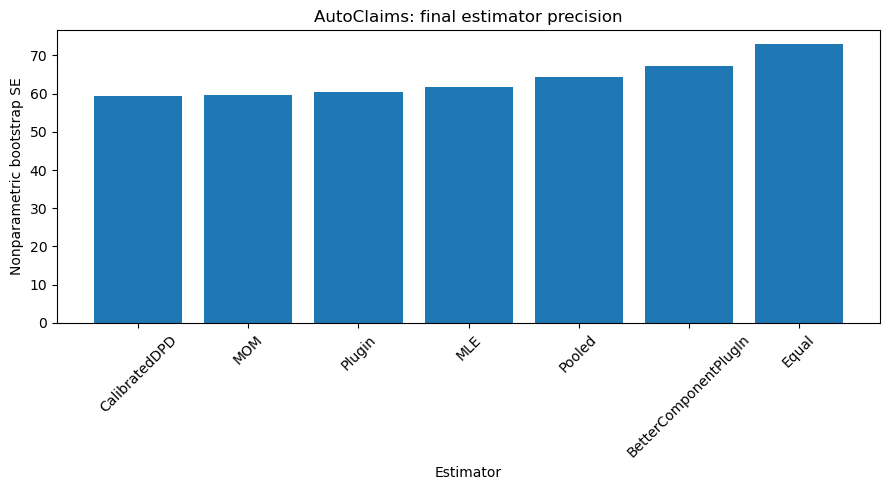


MULTI-DATASET WORKFLOW COMPLETED
Selected dataset = AutoClaims
Selected feature = GENDER
Selected group 1 = M
Selected group 2 = F
Selected tau = 0.01
Final mean gap = 5.1845%
DPD top performance = True
Output directory = C:\Users\jzhou\Desktop\Academics\Research\Common Mean for Gamma Distribution\New Submission with Adaptive MLE\Code\multidataset_common_mean_dpd_outputs


In [10]:
# ============================================================
# 10. Save results and figures
# ============================================================

candidate_screen.to_csv(
    OUTPUT_DIR
    / "all_dataset_candidate_screen.csv",
    index=False,
)

stable_candidates.to_csv(
    OUTPUT_DIR
    / "stable_shortlist.csv",
    index=False,
)

development_performance.to_csv(
    OUTPUT_DIR
    / "development_performance.csv",
    index=False,
)

final_estimator_results.to_csv(
    OUTPUT_DIR
    / "final_estimator_results.csv",
    index=False,
)

final_stress_records.to_csv(
    OUTPUT_DIR
    / "final_stress_records.csv",
    index=False,
)

final_stress_summary.to_csv(
    OUTPUT_DIR
    / "final_stress_summary.csv",
    index=False,
)

settings = {
    "datasets": list(
        prepared_datasets.keys()
    ),
    "dataset_sources": (
        dataset_sources
    ),
    "seed": int(SEED),
    "publication_mode": bool(
        PUBLICATION_MODE
    ),
    "development_fraction": float(
        DEVELOPMENT_FRACTION
    ),
    "selected_dataset": (
        SELECTED_DATASET
    ),
    "selected_feature": (
        SELECTED_FEATURE
    ),
    "selected_level_1": (
        SELECTED_LEVEL_1
    ),
    "selected_level_2": (
        SELECTED_LEVEL_2
    ),
    "selected_tau": float(
        SELECTED_TAU
    ),
    "final_mean_gap": float(
        FINAL_MEAN_GAP
    ),
    "final_compatibility": bool(
        FINAL_COMPATIBILITY
    ),
    "final_dpd_se_rank": int(
        FINAL_DPD_SE_RANK
    ),
    "final_dpd_rmse_wins": int(
        FINAL_DPD_RMSE_WINS
    ),
    "final_dpd_displacement_wins": int(
        FINAL_DPD_DISPLACEMENT_WINS
    ),
    "final_dpd_mle_drift": float(
        FINAL_DPD_MLE_DRIFT
    ),
    "dpd_top_performance": bool(
        DPD_TOP_PERFORMANCE
    ),
}

with open(
    OUTPUT_DIR
    / "analysis_settings.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        settings,
        file,
        indent=2,
        default=str,
    )


fig, ax = plt.subplots(
    figsize=(9, 5)
)

plot_results = (
    final_estimator_results.sort_values(
        "bootstrap_se"
    )
)

ax.bar(
    plot_results["estimator"],
    plot_results["bootstrap_se"],
)

ax.set_xlabel("Estimator")
ax.set_ylabel(
    "Nonparametric bootstrap SE"
)
ax.set_title(
    f"{SELECTED_DATASET}: final estimator precision"
)
ax.tick_params(
    axis="x",
    rotation=45,
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR
    / "final_estimator_se.png",
    dpi=300,
)
plt.show()


print()
print("=" * 96)
print("MULTI-DATASET WORKFLOW COMPLETED")
print("Selected dataset =", SELECTED_DATASET)
print("Selected feature =", SELECTED_FEATURE)
print("Selected group 1 =", SELECTED_LEVEL_1)
print("Selected group 2 =", SELECTED_LEVEL_2)
print("Selected tau =", SELECTED_TAU)
print(
    "Final mean gap =",
    f"{FINAL_MEAN_GAP:.4%}",
)
print(
    "DPD top performance =",
    DPD_TOP_PERFORMANCE,
)
print(
    "Output directory =",
    OUTPUT_DIR.resolve(),
)
print("=" * 96)


In [11]:
# 1. Save the DataFrame to a CSV
csv_path = OUTPUT_DIR / "final_estimator_results.csv"
final_estimator_results.to_csv(csv_path, index=False)
print(f"Saved results to: {csv_path}")

# 2. Load the CSV back into a DataFrame
loaded_results = pd.read_csv(csv_path)

# Display the loaded DataFrame
loaded_results

Saved results to: multidataset_common_mean_dpd_outputs\final_estimator_results.csv


,estimator,estimate,bootstrap_mean,bootstrap_bias,bootstrap_se,ci_lower,ci_upper,successful_replications,se_rank
0,Equal,"1,935.295311","1,926.448004",-8.847307,72.899769,"1,798.856766","2,061.054439",200,7.000000
1,Pooled,"1,923.346029","1,914.690823",-8.655205,64.297167,"1,803.295492","2,030.744744",200,5.000000
2,BetterComponentPlugIn,"1,885.128076","1,877.087279",-8.040797,67.127820,"1,750.576765","2,014.966886",200,6.000000
3,Plugin,"1,908.435533","1,893.916804",-14.518729,60.336326,"1,780.693256","2,006.078384",200,3.000000
4,MOM,"1,910.342513","1,899.296402",-11.046112,59.710291,"1,786.141047","2,006.083299",200,2.000000
5,MLE,"1,919.045670","1,908.811111",-10.234559,61.714924,"1,800.073825","2,016.337429",200,4.000000
6,CalibratedDPD,"1,897.184691","1,887.664928",-9.519762,59.337868,"1,779.023829","1,989.933863",200,1.000000
